In [1]:
import torch.nn as nn
import torch
import pandas as pd
import numpy as np
import copy

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv("data/Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## **Descripción de la tarea**

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### **Explicación del dataset**
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

El dataset contiene información de los Pokémon de primera a sexta generación, incluyendo sus estadísticas, tipos elementales, generación y una variable indicadora de si son o no legendarios. También incluye un identificador único de cada Pokémon, el cual puede repetirse para distintas versiones del mismo, como megaevoluciones, diferentes formas (como en el caso de Tornadus), tamaños, etc.

#### **Descripción de las columnas:**

| Columna    | Tipo de dato | Descripción                                                                                                       |
| :--------- | :----------- | :---------------------------------------------------------------------------------------------------------------- |
| #          | Numérica     | Identificador único para distinguir los Pokémon; se repite si un mismo Pokémon tiene múltiples formas o versiones |
| Name       | String       | Nombre del Pokémon o de su versión específica                                                                     |
| Type 1     | String       | Tipo elemental primario del Pokémon                                                                               |
| Type 2     | String o NaN | Tipo elemental secundario del Pokémon                                                                             |
| Total      | Numérica     | Suma total de las estadísticas                                                                                    |
| HP         | Numérica     | Puntos de vida del Pokémon                                                                                        |
| Attack     | Numérica     | Puntos de ataque del Pokémon                                                                                      |
| Defense    | Numérica     | Puntos de defensa del Pokémon                                                                                     |
| Sp. Atk    | Numérica     | Puntos de ataque especial del Pokémon                                                                             |
| Sp. Def    | Numérica     | Puntos de defensa especial del Pokémon                                                                            |
| Speed      | Numérica     | Puntos de velocidad del Pokémon                                                                                   |
| Generation | Numérica     | Variable categórica numérica que indica la generación del Pokémon                                                 |
| Legendary  | Booleana     | Variable indicadora que señala si el Pokémon es legendario                                                        |

#### **Consideraciones**

Se debe tener en cuenta, al analizar el dataset, la existencia del *power creep* en Pokémon, donde los Pokémon de generaciones más recientes tienden a ser más fuertes que los de generaciones anteriores. Esto podría generar que algunos Pokémon de primera generación no sean identificados como legendarios por el modelo.

También es importante considerar que el dataset está desbalanceado por naturaleza, ya que existen aproximadamente 60 Pokémon legendarios, mientras que el resto corresponde a Pokémon no legendarios.

Finalmente, se debe tener en cuenta la presencia de los pseudo-legendarios, que son Pokémon cuyas estadísticas totales superan los 600 puntos, pero que no son clasificados como legendarios.

### **Preparación del dataset**

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [3]:
# Primer filtro, quitar las distintas versiones de un mismo pokemon.
# Esto quita duplicados guiandose por la columna #, y se queda con la primera fila en casos de duplicados (Porque notamos que el dataset venia ordenado, osea las versiones de Charizar estaban debajo de el pokemon Charizard)
# # | Pokemon
# 6 | Charizard
# 6 | CharizardMega Charizard X
# 6 | CharizardMega Charizard Y
# Entonces nos quedamos con el primero simplemente agrupando por #
df_clean = data.drop_duplicates(subset="#", keep="first").copy()

# Segundo filtro, aplicar el one hot encoding a las variables categoricas (Type 1, Type2 y Generacion)
# Se rellenan los NaN con None, para aplicar los dummies
df_clean["Type 2"] = df_clean["Type 2"].fillna("None")
# Se aplica el get dummies, que pasa las posibles valores de la columna a columnas tipo flag
df_encoded = pd.get_dummies(
    df_clean,
    columns=["Type 1", "Type 2", "Generation"],
    prefix=["T1", "T2", "Gen"]
)


In [4]:
# Importante: se elimina "Legendary" del X (es la variable objetivo, dejarla seria fuga de target).
# Tambien se quita "Total" (suma de stats individuales, redundancia), "#" (id sin valor predictivo) y "Name".
X = df_encoded.drop(columns=["Total", "#", "Name", "Legendary"])  # Inputs
y = df_encoded["Legendary"]                                       # Objetivo


In [5]:
# Convertir bool a int en todo el DataFrame X
X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})

# Convertir Legendary a int
y = y.astype(int)


### **Definición del modelo**  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

Se Definieron 3 arquiteturas que vanL

- 50 Neuronas -> 16 Neuronas -> 1 Neurona
- 50 Neuronas -> 32 Neuronas -> 16 Neuronas -> 1 Neurona
- 50 Neuronas -> 32 Neuronas -> 32 Neuronas -> 16 Neuronas -> 1 Neurona

In [6]:
from models import MLP1, MLP2, MLP3

model1 = MLP1(input_dim=X.shape[1])
model2 = MLP2(input_dim=X.shape[1])
model3 = MLP3(input_dim=X.shape[1])

### **Definición de optimizador y función de costo**
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)

### **Entrenamiento del modelo**
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

In [8]:
# Split estratificado para mantener proporcion de legendarios en train/val.
# Usamos indices posicionales para luego poder mapear los errores de vuelta a df_clean.
indices = np.arange(len(X))
idx_train, idx_val, y_train, y_val = train_test_split(
    indices,
    y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values,
)

X_train_df = X.iloc[idx_train].copy()
X_val_df = X.iloc[idx_val].copy()

# Estandarizamos las columnas numericas. Fit solo en train para evitar fuga.
NUMERIC_COLS = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
scaler = StandardScaler()
X_train_df[NUMERIC_COLS] = scaler.fit_transform(X_train_df[NUMERIC_COLS])
X_val_df[NUMERIC_COLS] = scaler.transform(X_val_df[NUMERIC_COLS])

X_train_tensor = torch.tensor(X_train_df.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_df.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# pos_weight para compensar el desbalance: hay muchos mas no-legendarios que legendarios.
n_pos = float(y_train.sum())
n_neg = float(len(y_train) - n_pos)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight = {pos_weight.item():.3f} (n_neg/n_pos = {n_neg:.0f}/{n_pos:.0f})")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


pos_weight = 14.568 (n_neg/n_pos = 539/37)


In [9]:
epochs = 100
patience = 10

best_val_loss = float("inf")
best_state = copy.deepcopy(model1.state_dict())
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model1.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer1.zero_grad()

        outputs = model1(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer1.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model1.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model1(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    avg_train = total_loss / len(loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}")

    # -------- EARLY STOPPING + GUARDADO DEL MEJOR MODELO --------
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model1.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

# Restauramos los pesos con menor val_loss (no los ultimos)
model1.load_state_dict(best_state)
print(f"Mejor val_loss = {best_val_loss:.4f} restaurado.")


Epoch 1, Train Loss: 1.2587, Val Loss: 1.1413
Epoch 2, Train Loss: 1.1545, Val Loss: 1.0606
Epoch 3, Train Loss: 1.0509, Val Loss: 0.9693
Epoch 4, Train Loss: 0.9340, Val Loss: 0.8827
Epoch 5, Train Loss: 0.8329, Val Loss: 0.7954
Epoch 6, Train Loss: 0.7323, Val Loss: 0.7138
Epoch 7, Train Loss: 0.6337, Val Loss: 0.6441
Epoch 8, Train Loss: 0.5667, Val Loss: 0.5814
Epoch 9, Train Loss: 0.4978, Val Loss: 0.5282
Epoch 10, Train Loss: 0.4460, Val Loss: 0.4907
Epoch 11, Train Loss: 0.3781, Val Loss: 0.4585
Epoch 12, Train Loss: 0.3551, Val Loss: 0.4282
Epoch 13, Train Loss: 0.3307, Val Loss: 0.4042
Epoch 14, Train Loss: 0.2989, Val Loss: 0.3879
Epoch 15, Train Loss: 0.2860, Val Loss: 0.3748
Epoch 16, Train Loss: 0.2590, Val Loss: 0.3610
Epoch 17, Train Loss: 0.2469, Val Loss: 0.3539
Epoch 18, Train Loss: 0.2320, Val Loss: 0.3462
Epoch 19, Train Loss: 0.2254, Val Loss: 0.3382
Epoch 20, Train Loss: 0.2089, Val Loss: 0.3257
Epoch 21, Train Loss: 0.2030, Val Loss: 0.3217
Epoch 22, Train Loss: 

In [10]:
epochs = 100
patience = 10

best_val_loss = float("inf")
best_state = copy.deepcopy(model2.state_dict())
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model2.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer2.zero_grad()

        outputs = model2(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model2.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model2(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    avg_train = total_loss / len(loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}")

    # -------- EARLY STOPPING + GUARDADO DEL MEJOR MODELO --------
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model2.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

# Restauramos los pesos con menor val_loss (no los ultimos)
model2.load_state_dict(best_state)
print(f"Mejor val_loss = {best_val_loss:.4f} restaurado.")


Epoch 1, Train Loss: 1.2535, Val Loss: 1.1985
Epoch 2, Train Loss: 1.1094, Val Loss: 1.0662
Epoch 3, Train Loss: 0.9728, Val Loss: 0.9017
Epoch 4, Train Loss: 0.8318, Val Loss: 0.7932
Epoch 5, Train Loss: 0.7440, Val Loss: 0.7010
Epoch 6, Train Loss: 0.6420, Val Loss: 0.6303
Epoch 7, Train Loss: 0.5820, Val Loss: 0.5730
Epoch 8, Train Loss: 0.5079, Val Loss: 0.5188
Epoch 9, Train Loss: 0.4537, Val Loss: 0.4697
Epoch 10, Train Loss: 0.3777, Val Loss: 0.4340
Epoch 11, Train Loss: 0.3246, Val Loss: 0.4151
Epoch 12, Train Loss: 0.2760, Val Loss: 0.4170
Epoch 13, Train Loss: 0.2770, Val Loss: 0.3781
Epoch 14, Train Loss: 0.2703, Val Loss: 0.3554
Epoch 15, Train Loss: 0.1914, Val Loss: 0.3583
Epoch 16, Train Loss: 0.1737, Val Loss: 0.3750
Epoch 17, Train Loss: 0.1560, Val Loss: 0.3593
Epoch 18, Train Loss: 0.1774, Val Loss: 0.4195
Epoch 19, Train Loss: 0.1339, Val Loss: 0.4596
Epoch 20, Train Loss: 0.1085, Val Loss: 0.4605
Epoch 21, Train Loss: 0.1312, Val Loss: 0.4130
Epoch 22, Train Loss: 

In [11]:
epochs = 100
patience = 10

best_val_loss = float("inf")
best_state = copy.deepcopy(model3.state_dict())
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model3.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer3.zero_grad()

        outputs = model3(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer3.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model3.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model3(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    avg_train = total_loss / len(loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}")

    # -------- EARLY STOPPING + GUARDADO DEL MEJOR MODELO --------
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model3.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

# Restauramos los pesos con menor val_loss (no los ultimos)
model3.load_state_dict(best_state)
print(f"Mejor val_loss = {best_val_loss:.4f} restaurado.")


Epoch 1, Train Loss: 1.2389, Val Loss: 1.2200
Epoch 2, Train Loss: 1.1391, Val Loss: 1.1148
Epoch 3, Train Loss: 1.0089, Val Loss: 0.9616
Epoch 4, Train Loss: 0.9203, Val Loss: 0.8394
Epoch 5, Train Loss: 0.7914, Val Loss: 0.7460
Epoch 6, Train Loss: 0.7058, Val Loss: 0.6735
Epoch 7, Train Loss: 0.6331, Val Loss: 0.5950
Epoch 8, Train Loss: 0.5382, Val Loss: 0.5186
Epoch 9, Train Loss: 0.4939, Val Loss: 0.4455
Epoch 10, Train Loss: 0.4585, Val Loss: 0.4050
Epoch 11, Train Loss: 0.3392, Val Loss: 0.3698
Epoch 12, Train Loss: 0.3714, Val Loss: 0.3383
Epoch 13, Train Loss: 0.3551, Val Loss: 0.3262
Epoch 14, Train Loss: 0.2786, Val Loss: 0.2876
Epoch 15, Train Loss: 0.2913, Val Loss: 0.2731
Epoch 16, Train Loss: 0.2445, Val Loss: 0.2677
Epoch 17, Train Loss: 0.2020, Val Loss: 0.2955
Epoch 18, Train Loss: 0.2345, Val Loss: 0.2636
Epoch 19, Train Loss: 0.2127, Val Loss: 0.2496
Epoch 20, Train Loss: 0.2030, Val Loss: 0.2445
Epoch 21, Train Loss: 0.1521, Val Loss: 0.2349
Epoch 22, Train Loss: 

### **Evaluación del modelo**
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

In [12]:

def evaluar_modelo(model, X, y, threshold=0.5):
    model.eval()
    
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    y_true = y.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # 🔥 etiquetas personalizadas
    labels = ["No Legendario", "Legendario"]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    return cm, acc, prec, rec, f1

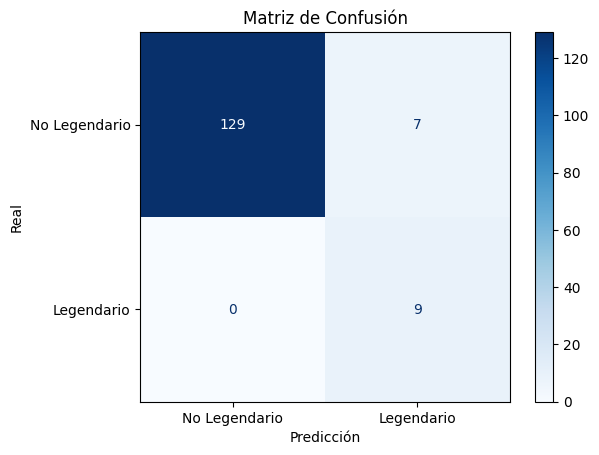

Accuracy : 0.9517
Precision: 0.5625
Recall   : 1.0000
F1-score : 0.7200


In [13]:
cm = evaluar_modelo(model1, X_val_tensor, y_val_tensor)


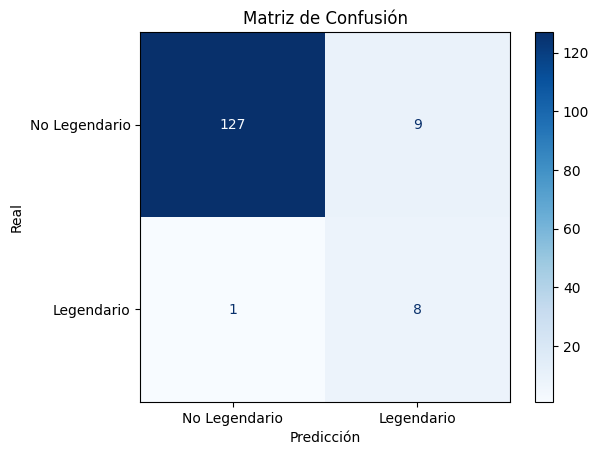

Accuracy : 0.9310
Precision: 0.4706
Recall   : 0.8889
F1-score : 0.6154


In [14]:
cm = evaluar_modelo(model2, X_val_tensor, y_val_tensor)


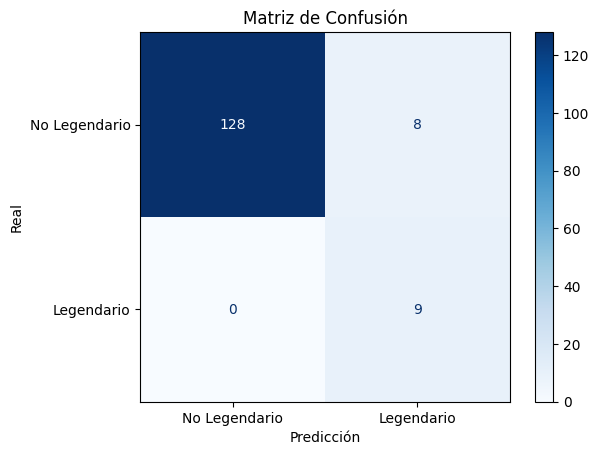

Accuracy : 0.9448
Precision: 0.5294
Recall   : 1.0000
F1-score : 0.6923


In [15]:
cm = evaluar_modelo(model3, X_val_tensor, y_val_tensor)


In [16]:
def obtener_errores(model, X, y, threshold=0.5):
    model.eval()

    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    y_true = y.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    # indices donde se equivoca (posiciones dentro del set de validacion)
    errores_idx = (y_true != y_pred)

    return errores_idx, y_true, y_pred, probs.cpu().numpy().ravel()

errores_idx, y_true, y_pred, probs = obtener_errores(model1, X_val_tensor, y_val_tensor)

# Posiciones dentro de val que fallaron
fallidos_en_val = np.where(errores_idx)[0]

# Mapeamos esas posiciones de vuelta a las filas originales de df_clean.
# idx_val contiene las posiciones (en df_clean reset_index) de las muestras de validacion.
idxs_originales = idx_val[fallidos_en_val]
df_eval = df_clean.reset_index(drop=True).iloc[idxs_originales].copy()
df_eval["Probabilidad"] = probs[fallidos_en_val]
df_eval["Predicho_Legendario"] = y_pred[fallidos_en_val].astype(bool)

# Columnas relevantes
df_eval[["Name", "Type 1", "Type 2", "Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Legendary", "Predicho_Legendario", "Probabilidad"]]


,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Predicho_Legendario,Probabilidad
375,Metagross,Steel,Psychic,600,80,135,130,95,90,70,False,True,0.943891
487,Cresselia,Psychic,None,600,120,70,120,75,130,85,False,True,0.969788
250,Celebi,Psychic,Grass,600,100,100,100,100,100,100,False,True,0.958445
247,Tyranitar,Rock,Dark,600,100,134,110,95,100,61,False,True,0.827498
391,Infernape,Fire,Fighting,534,76,104,71,104,71,108,False,True,0.664733
195,Espeon,Psychic,None,525,65,65,60,130,95,110,False,True,0.693182
474,Gallade,Psychic,Fighting,518,68,125,65,65,115,80,False,True,0.747939


### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.
2. ¿En qué parte o partes de la tarea utilizó estas herramientas?